In [42]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from colorama import Fore

from sklearn.model_selection import train_test_split, GridSearchCV

# Models
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier


from sklearn.metrics._classification import (accuracy_score,
                                             confusion_matrix,
                                             precision_score,
                                             recall_score,
                                             f1_score,
                                             classification_report)


# Overfiting: 
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE


In [43]:
os.listdir()

['classification.ipynb',
 'EDA.ipynb',
 'machine_learning.ipynb',
 'machine_learning_test_ok.ipynb',
 'preprocessong.ipynb',
 'Task 1.txt']

In [44]:
df = pd.read_csv('../data/preprocessing data/preprocessing_data.csv')

In [45]:
df.shape

(7043, 20)

In [46]:
# 1. DATEN VORBEREITEN (Wichtig: Vor dem Split!)
# Leerzeichen in TotalCharges entfernen und zu Zahlen umwandeln
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(' ', '0'))
df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'].replace(' ', '0'))

# 2. Sicherstellen, dass die Spalte wirklich numerisch ist
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

In [47]:
df.sample()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
34,Male,1,No,No,1,Yes,No,DSL,No,No,No,No,No,No,0,No,Bank transfer (automatic),45.25,45.25,0


## Split freatures into X and y

In [48]:
X = df.drop( columns= 'Churn')
y = df['Churn']

## Split into training and testing

In [49]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [50]:
X_train.shape

(5634, 19)

# Model Selection
### Getting your preprocessing Pipiline ready!

In [51]:
df.sample()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
4665,Female,0,Yes,Yes,67,No,No phone service,DSL,Yes,Yes,No,No,No,No,2,No,Bank transfer (automatic),36.15,2434.45,0


- Alle String Columns mit Namen auswählen 

In [52]:
# 1. Den Transformer definieren
preprocessing_step = ColumnTransformer([
    ( 'One-Hot Encoding', OneHotEncoder(), [ 
        'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 
        'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
        'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'PaymentMethod' 
    ]),                                           
], remainder='passthrough')

# 2. Den Transformer auf deine Daten (z.B. df) ANWENDEN
# data_transformed = preprocessing_step.fit_transform(df)

preprocessing_step

,transformers,"[('One-Hot Encoding', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,None
,sparse_output,True


In [53]:
# 1 KNN
knn_model = KNeighborsClassifier(  )

In [54]:
#Hier braucht: from imblearn.pipeline import Pipeline as ImbPipeline

knn_pipeline = ImbPipeline([
    ('preprocessing', preprocessing_step),
    ('Scaling', StandardScaler()),
    ('KNN-Model', KNeighborsClassifier())
])

# Hier kannst du direkt X und y (mit den Strings) übergeben
knn_pipeline.fit(X, y)

,steps,"[('preprocessing', ...), ('Scaling', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('One-Hot Encoding', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [55]:
# 4. EVALUATIONS-FUNKTION (angepasst)
def evaluate_classifier(model, model_name, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    # print( model_name + ' :' + '\n' )

    
    acc_train = round(model.score(X_train, y_train) * 100, 2)
    acc_test = round(model.score(X_test, y_test) * 100, 2)
    
    # Da y jetzt 0/1 ist, funktioniert precision_score ohne extra pos_label
    precision = round(precision_score(y_test, y_pred) * 100, 2)
    recall = round(recall_score(y_test, y_pred) * 100, 2)
    f1 = round(f1_score(y_test, y_pred) * 100, 2)
    
    print(f'{model_name}:\n')
    print(f'Training Acc : {acc_train}%')
    print(f'Testing Acc : {acc_test}%')
    print(Fore.RED + f'Recall: {recall}%')
    print(Fore.WHITE + f'Precision: {precision}%')
    print(Fore.WHITE + f'F1-Score: {f1}%')
    
    my_style = {
        'color': 'red', 'family': 'Arial', 'fontsize': 25}
    # Confusion Matrix Plot
    conf_mat = confusion_matrix(y_test, y_pred)
    sns.heatmap(conf_mat, cmap='Blues', annot=True,
                 fmt='d', annot_kws={'fontsize': 25})
    plt.title('Confusion Matrix', fontsize=25)

    plt.xlabel('Predicted', fontdict=my_style)
    plt.xticks(  [0.5, 1.5],labels= [ 'False Negative', 'True Posetive'], fontsize= 15)

    plt.ylabel('Actual',  fontdict=my_style)
    plt.yticks( [0.5, 1.5 ], labels= [ 'TN | FP', 'FN | TP'], fontsize= 15, rotation=00)
    
    plt.show()

#### Define a function to quickly evaluate your regressor !

KNN with Scaling:

Training Acc : 83.3%
Testing Acc : 75.94%
Recall: 48.26%
Precision: 55.21%
F1-Score: 51.5%


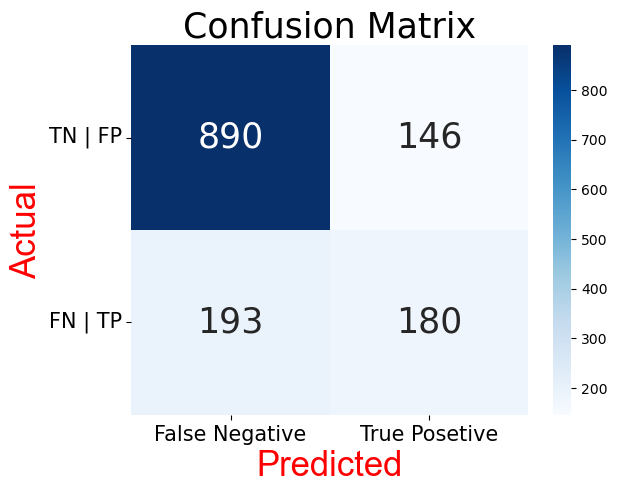

In [56]:
# 5. STARTEN
evaluate_classifier(knn_pipeline, 'KNN with Scaling', X_train, X_test, y_train, y_test)

### Die 4 Felder erklärt:
- Oben links (True Negative - TN):
Das Modell sagt „No“ (0) und es ist auch „No“.
Bedeutung: Kunden, die geblieben sind und richtig erkannt wurden.

- Oben rechts (False Positive - FP):
Das Modell sagt „Yes“ (1), aber es ist eigentlich „No“.
Bedeutung: Fehlalarm. Das Modell dachte, der Kunde kündigt, aber er bleibt.

- Unten links (False Negative - FN):
Das Modell sagt „No“ (0), aber es ist eigentlich „Yes“.
Bedeutung: Verpasster Kündiger. Das ist oft der „teuerste“ Fehler, weil du den Kunden verlierst, ohne es zu merken.

- Unten rechts (True Positive - TP):
Das Modell sagt „Yes“ (1) und es ist auch „Yes“.
Bedeutung: Volltreffer. Kunden, die wirklich kündigen wollten und erkannt wurden.


## Try 1st Techniqu: Under- Sampling

In [57]:
from imblearn.under_sampling import RandomUnderSampler
# pip install imblearn
# pip install imbalanced-learn

In [58]:
under_sampler = RandomUnderSampler( )

In [59]:
X_under, y_under = under_sampler.fit_resample( X, y )

In [60]:
len ( X_under ), len( y_under )

(3738, 3738)

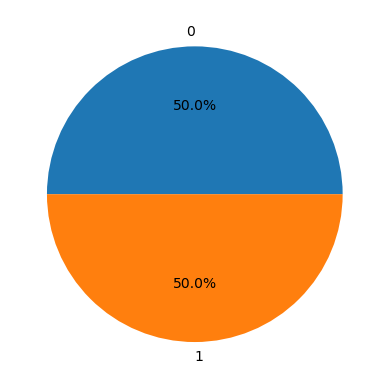

In [61]:
plt.pie( x= y_under.value_counts(),
        labels= y_under.value_counts().index, autopct=  '%1.1f%%');

## Create new train & test under sampled data

In [62]:
X_train_U, X_test_U, y_train_U, y_test_U = train_test_split( X_under, y_under, test_size=0.2, random_state=42)

In [63]:
len( X_train_U)

2990

In [64]:
knn_pipeline

,steps,"[('preprocessing', ...), ('Scaling', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('One-Hot Encoding', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# This Model down is better than first 

KNN with Randomundersampler:

Training Acc : 79.6%
Testing Acc : 72.59%
Recall: 79.13%
Precision: 69.52%
F1-Score: 74.02%


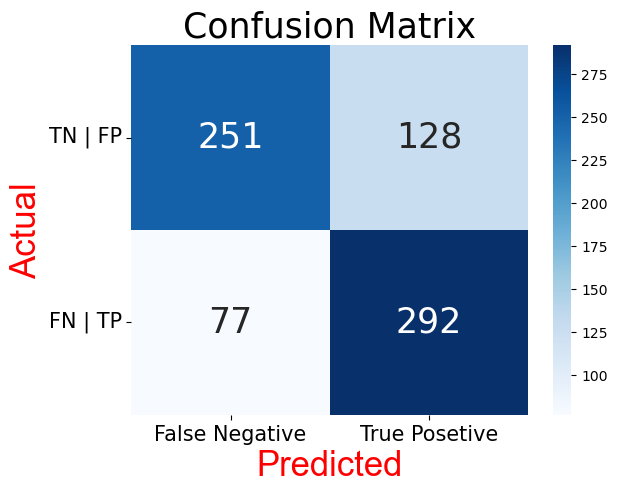

In [65]:
evaluate_classifier( knn_pipeline, 'KNN with Randomundersampler', X_train_U, X_test_U , y_train_U, y_test_U)

### Die 4 Felder erklärt:
- Oben links (True Negative - TN):
Das Modell sagt „No“ (0) und es ist auch „No“.
Bedeutung: Kunden, die geblieben sind und richtig erkannt wurden.

- Oben rechts (False Positive - FP):
Das Modell sagt „Yes“ (1), aber es ist eigentlich „No“.
Bedeutung: Fehlalarm. Das Modell dachte, der Kunde kündigt, aber er bleibt.

- Unten links (False Negative - FN):
Das Modell sagt „No“ (0), aber es ist eigentlich „Yes“.
Bedeutung: Verpasster Kündiger. Das ist oft der „teuerste“ Fehler, weil du den Kunden verlierst, ohne es zu merken.

- Unten rechts (True Positive - TP):
Das Modell sagt „Yes“ (1) und es ist auch „Yes“.
Bedeutung: Volltreffer. Kunden, die wirklich kündigen wollten und erkannt wurden.


## Try Random-Over-Sampling

In [66]:
from imblearn.over_sampling import RandomOverSampler

In [67]:
over_sampler = RandomOverSampler( random_state = 42 )

In [68]:
X_over, y_over = over_sampler.fit_resample( X, y )

In [69]:
len( X_over ), len( y_over )

(10348, 10348)

In [70]:
y_over.value_counts()

Churn
0    5174
1    5174
Name: count, dtype: int64

In [71]:
X_over.duplicated().sum()

np.int64(3345)

<div style="font-family: Times New Roman; font-size: 200%;">
  Try<u style="font-size: 220%;">SMOTE</u>
</div>

In [72]:
from imblearn.over_sampling import SMOTE

In [73]:
smote = SMOTE(  )

In [74]:
# 1. Hier werden die Texte ('Female' etc.) in Zahlen umgewandelt
X_transformed = preprocessing_step.fit_transform(X)

#X_smote, y_smote =   smote.fit_resample( X, y )
X_smote, y_smote = smote.fit_resample( X_transformed, y )
y_smote.value_counts()

Churn
0    5174
1    5174
Name: count, dtype: int64

In [75]:
print(X.select_dtypes(include=['object', 'category']).columns)


Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling',
       'PaymentMethod'],
      dtype='object')


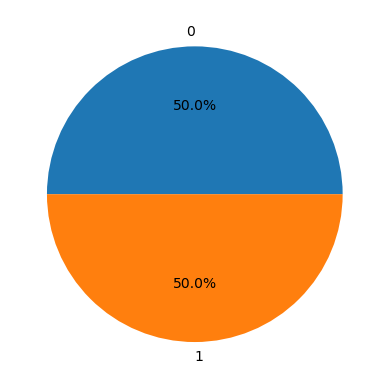

In [76]:
plt.pie( x= y_smote.value_counts(),
        labels = y_smote.value_counts().index, autopct= '%1.1f%%');

In [77]:
# X_smote.duplicated().sum()
## ---> FEhler:
# AttributeError: 'numpy.ndarray' object has no attribute 'duplicated'
## ------> Lösung: 1. Wandle X_smote zurück in einen DataFrame um

df_smote = pd.DataFrame( X_smote)

# Jetzt kannst du die Duplikate zählen
print(df_smote.duplicated().sum())

54


In [78]:
X_train_SM, X_test_SM, y_train_SM, y_test_SM = train_test_split( X_smote, y_smote, test_size=0.2, random_state=42)

In [79]:
knn_pipeline

,steps,"[('preprocessing', ...), ('Scaling', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('One-Hot Encoding', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


KNN after SMOTE:

Training Acc : 84.94%
Testing Acc : 80.1%
Recall: 89.7%
Precision: 75.58%
F1-Score: 82.04%


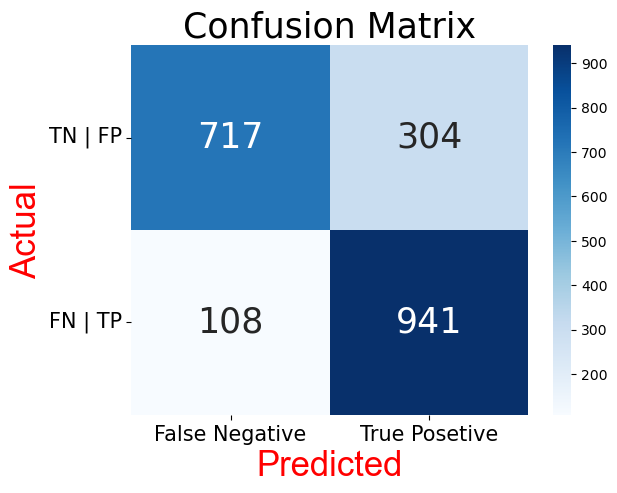

In [80]:
# Erstelle eine neue Pipeline nur für die bereits transformierten SMOTE-Daten
knn_pipeline = Pipeline([
    ('Scaling', StandardScaler()),
    ('KNN-Model', KNeighborsClassifier())
])

# Jetzt klappt der Aufruf
evaluate_classifier(knn_pipeline, 'KNN after SMOTE', X_train_SM, X_test_SM, y_train_SM, y_test_SM)



### Die 4 Felder erklärt:
- Oben links (True Negative - TN):
Das Modell sagt „No“ (0) und es ist auch „No“.
Bedeutung: Kunden, die geblieben sind und richtig erkannt wurden.

- Oben rechts (False Positive - FP):
Das Modell sagt „Yes“ (1), aber es ist eigentlich „No“.
Bedeutung: Fehlalarm. Das Modell dachte, der Kunde kündigt, aber er bleibt.

- Unten links (False Negative - FN):
Das Modell sagt „No“ (0), aber es ist eigentlich „Yes“.
Bedeutung: Verpasster Kündiger. Das ist oft der „teuerste“ Fehler, weil du den Kunden verlierst, ohne es zu merken.

- Unten rechts (True Positive - TP):
Das Modell sagt „Yes“ (1) und es ist auch „Yes“.
Bedeutung: Volltreffer. Kunden, die wirklich kündigen wollten und erkannt wurden.


In [81]:
import joblib

In [83]:
joblib.dump( knn_pipeline, '../data/artifacts/knn_pipeline.pkl')

['../data/artifacts/knn_pipeline.pkl']